In [2]:
import pandas as pd
df = pd.read_csv('/content/dataset_diagnostico_doencas_augmented.csv')

In [3]:
# Remove linhas onde a coluna alvo é nula antes de começar
df = df.dropna(subset=['Diagnóstico'])

In [4]:
df.head()

,Id,Nome,Idade,Sexo,Peso,Manchas,Temp,# Int.,Est.,Diagnóstico
0,4201,João,28,M,79,Concentradas,38.0,2,SP,Doente
1,3217,Maria,18,F,67,Inexistentes,39.5,4,MG,Doente
2,4039,Luiz,49,M,92,Espalhadas,38.0,2,RS,Saudável
3,1920,José,18,M,43,Inexistentes,38.5,8,MG,Doente
4,4340,Cláudia,21,F,52,Uniformes,37.6,1,PE,Saudável


In [5]:
df_processed = df.drop(columns=['Id','Nome','Est.'])

In [6]:
df_processed.columns

Index(['Idade', 'Sexo', 'Peso', 'Manchas', 'Temp', '# Int.', 'Diagnóstico'], dtype='object')

In [7]:
df_processed.rename(columns={'# Int.':'Internacoes','Diagnóstico':'Diagnostico'}, inplace=True)

In [8]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Idade        108 non-null    int64  
 1   Sexo         108 non-null    object 
 2   Peso         108 non-null    int64  
 3   Manchas      108 non-null    object 
 4   Temp         108 non-null    float64
 5   Internacoes  108 non-null    int64  
 6   Diagnostico  108 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 6.0+ KB


In [9]:
X = df_processed.drop(columns=['Diagnostico'])
y = df_processed['Diagnostico']

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

In [11]:
from sklearn.preprocessing import LabelEncoder
# Instancia o codificador
le = LabelEncoder()
# O modelo aprende as classes do treino e as transforma
y_train_encoded = le.fit_transform(y_train)
# O modelo APENAS transforma o teste usando o que aprendeu no treino
y_test_encoded = le.transform(y_test)

In [12]:
# Seleciona colunas numéricas (inteiros e decimais)
features_numericas = X_train.select_dtypes(include=['number']).columns
# Seleciona colunas categóricas (texto ou categoria)
features_categoricas = X_train.select_dtypes(include=['object', 'category']).columns

In [ ]:
features_numericas

Index(['Idade', 'Peso', 'Temp', 'Internacoes'], dtype='object')

In [ ]:
features_categoricas

Index(['Sexo', 'Manchas'], dtype='object')

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Pipeline para números
pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Preenche dados faltantes
    ('scaler', StandardScaler())                  # Normaliza os dados
])

# Pipeline para categorias
pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Preenche faltantes
    ('onehot', OneHotEncoder(handle_unknown='ignore'))      # Transforma em números
])

In [15]:
from sklearn.compose import ColumnTransformer
import joblib
from sklearn.neural_network import MLPClassifier

transformations = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, features_numericas),
        ('cat', pipeline_categorico, features_categoricas)
    ]
)

# Complete Pipeline with Preprocessor + Estimator
model_pipeline = Pipeline(steps=[
    ('transformations', transformations),
    ('classifier', MLPClassifier(max_iter=700))
])

# Fit on training data
model_pipeline.fit(X_train, y_train_encoded)

# Save the COMPLETE pipeline
joblib.dump(model_pipeline, 'modelo_final.pkl')

['modelo_final.pkl']

In [ ]:
#dados_transformados

### Cuidado com vazamento de dados<br>
fit_transform no Treino: O StandardScaler olha para o X_train, calcula a média e o desvio padrão daquela coluna e aplica a escala.

transform no Teste: O modelo aplica exatamente a mesma fórmula matemática nos dados de teste, usando a média do treino. Ele não olha para o X_test para recalcular nada.

Se você usasse fit_transform no teste, o scaler calcularia uma nova média baseada no teste. Isso faria seu modelo receber informações do futuro (informações do padrão dos dados de teste), gerando métricas falsamente excelentes que falhariam em produção.

In [ ]:
from sklearn.neural_network import MLPClassifier

modelo = MLPClassifier(max_iter=700) #com 200 (default) não converge
modelo.fit(dados_transformados, y_train_encoded)

X_test_processado = pipeline.transform(X_test)
y_pred_test = modelo.predict(X_test_processado)

y_pred_train = modelo.predict(dados_transformados)

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

      Doente       0.83      0.77      0.80        13
    Saudável       0.80      0.86      0.83        14

    accuracy                           0.81        27
   macro avg       0.82      0.81      0.81        27
weighted avg       0.82      0.81      0.81        27

--- MATRIZ DE CONFUSÃO ---


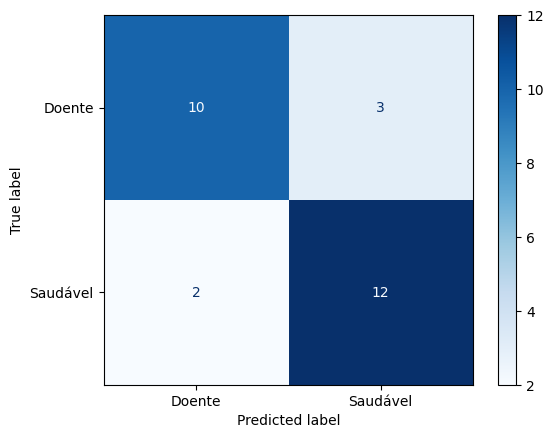

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Gerar o relatório de classificação (Precision, Recall, F1-Score)
print("--- RELATÓRIO DE CLASSIFICAÇÃO TEST SET ---")
print(classification_report(y_test_encoded, y_pred_test, target_names=le.classes_))

# 3. Gerar a matriz de confusão gráfica
print("--- MATRIZ DE CONFUSÃO TEST SET ---")
cm = confusion_matrix(y_test_encoded, y_pred_test)

# Exibir de forma visual usando os nomes originais das categorias
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

--- RELATÓRIO DE CLASSIFICAÇÃO TRAIN SET ---
              precision    recall  f1-score   support

      Doente       1.00      1.00      1.00        42
    Saudável       1.00      1.00      1.00        39

    accuracy                           1.00        81
   macro avg       1.00      1.00      1.00        81
weighted avg       1.00      1.00      1.00        81

--- MATRIZ DE CONFUSÃO TRAIN SET ---


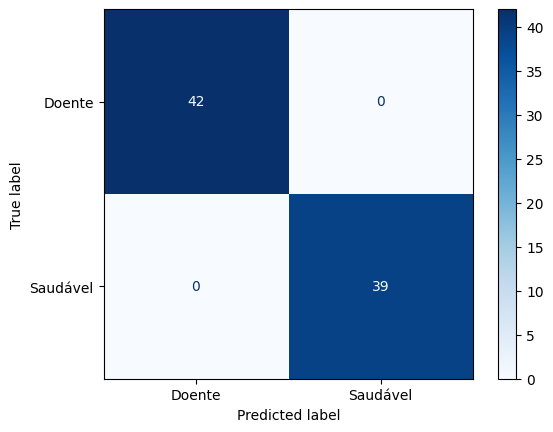

In [ ]:
# 1. Gerar o relatório de classificação (Precision, Recall, F1-Score)
print("--- RELATÓRIO DE CLASSIFICAÇÃO TRAIN SET ---")
print(classification_report(y_train_encoded, y_pred_train, target_names=le.classes_))

# 3. Gerar a matriz de confusão gráfica
print("--- MATRIZ DE CONFUSÃO TRAIN SET ---")
cm = confusion_matrix(y_train_encoded, y_pred_train)

# Exibir de forma visual usando os nomes originais das categorias
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
# No streamlit
import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(
    page_title="Predição de Diagnóstico - Doente vs Saudável",
    page_icon="🏥",
    layout="wide"
)

st.title(" Sistema de Suporte ao Diagnóstico Clínico")
st.markdown("""
Esta aplicação utiliza um modelo de **Machine Learning** pré-treinado para auxiliar no diagnóstico de pacientes.
Preencha os dados clínicos abaixo e clique em **Realizar Diagnóstico**.
""")

@st.cache_resource
def load_pipeline():
    """
    Carrega o arquivo do Pipeline/Modelo treinado.
    O decorator @st.cache_resource otimiza a performance mantendo o modelo em memória.
    """
    try:
        pipeline = joblib.load("modelo_final.pkl")
        return pipeline
    except Exception as e:
        st.error(f"Erro ao carregar o modelo: {e}")
        return None

pipeline = load_pipeline()

# -----------------------------------------------------------------------------
# Formulário da UI para Coleta de Dados
# -----------------------------------------------------------------------------
st.sidebar.header("📋 Parâmetros do Paciente")

with st.form(key="patient_form"):
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Dados Biométricos & Vitais")
        idade = st.number_input("Idade (anos)", min_value=1, max_value=120, value=45, step=1)
        peso = st.number_input("Peso (Kg)", min_value=40.0, max_value=150.0, value=60.0)
        temperatura = st.number_input("Temperatura", min_value=30.0, max_value=40.0, value=37.0)
        internacoes = st.number_input("Internações", min_value=0, max_value=20, value=1)

    with col2:
        st.subheader("Categóricos")
        sexo = st.selectbox("Sexo", options=["M", "F"])
        manchas = st.selectbox("Manchas", options=["Concentradas", "Inexistentes","Espalhadas","Uniformes"])

    # Botão de submissão do formulário
    submit_button = st.form_submit_button(label="Realizar Diagnóstico")

# -----------------------------------------------------------------------------
# Tratamento e Aplicação no Pipeline para Inferência
# -----------------------------------------------------------------------------
if submit_button:
    if pipeline is None:
        st.error("O pipeline não está carregado. Verifique o arquivo .pkl.")
    else:
        # A. Construção do DataFrame respeitando os nomes e tipos exatos do treino
        input_data = pd.DataFrame([{
            'idade': int(idade),
            'peso': float(peso),
            'temperatura': float(temperatura),
            'internacoes': int(internacoes),
            'sexo': str(sexo),
            'manchas': str(manchas)
        }])

        # B. Exibição dos dados de entrada formatados na tela
        st.markdown("---")
        st.subheader("Dados Coletados para Inferência")
        st.dataframe(input_data)

        # Predição usando o Pipeline
        try:
            # Predição da Classe (Ex: 0 = Saudável, 1 = Doente)
            prediction = pipeline.predict(input_data)[0]

            # Predição da Probabilidade (se suportado pelo modelo)
            has_proba = hasattr(pipeline, "predict_proba")
            if has_proba:
                probabilities = pipeline.predict_proba(input_data)[0]

            # Apresentação dos Resultados
            st.markdown("### Resultado da Avaliação")

            if prediction == 1 or str(prediction).lower() == 'doente':
                st.error("Paciente Propenso / Doente")
            else:
                st.success("Paciente Saudável")

            # Exibição do nível de confiança/probabilidade
            if has_proba:
                prob_doente = probabilities[1] if len(probabilities) > 1 else probabilities[0]
                st.write(f"Probabilidade estimada de doença: `{prob_doente * 100:.2f}%`")
                st.progress(float(prob_doente))

        except Exception as err:
            st.error(f"Erro ao processar a inferência através do pipeline: {err}")